In [25]:
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from scipy.stats import gaussian_kde, entropy
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.base import clone  # Added missing import
# import shap
# from tqdm import tqdm
# from sklearn.metrics import r2_score  # Added for completeness

# class ESHAPExplainer:
#     def __init__(self, model, X_train, y_train, beta=5.0, random_state=None):
#         """
#         Initialize E-SHAP explainer
        
#         Args:
#             model: Trained tree ensemble model (RandomForest, XGBoost, etc.)
#             X_train: Training features
#             y_train: Training labels
#             beta: Temperature parameter for softmax weighting
#             random_state: Random seed
#         """
#         self.model = model
#         self.X_train = X_train
#         self.y_train = y_train
#         self.beta = beta
#         self.random_state = random_state
#         self.weights_ = self._compute_tree_weights()
#         self.full_explainer = shap.TreeExplainer(model)
        
#     def _compute_tree_weights(self):
#         """Compute tree weights based on performance"""
#         if hasattr(self.model, 'estimators_'):
#             scores = []
#             for tree in self.model.estimators_:
#                 pred = tree.predict(self.X_train)
#                 if len(pred.shape) > 1 and pred.shape[1] > 1:  # Classification
#                     score = accuracy_score(self.y_train, np.argmax(pred, axis=1))
#                 else:  # Regression
#                     score = r2_score(self.y_train, pred)
#                 scores.append(score)
            
#             # Softmax weighting with temperature control
#             max_score = np.max(scores)
#             exp_vals = np.exp(self.beta * (np.array(scores) - max_score))
#             return exp_vals / np.sum(exp_vals)
#         else:
#             # Single tree model
#             return np.array([1.0])
    
#     def explain(self, x, n_samples=500, alpha=1.0):
#         """
#         Compute E-SHAP values with uncertainty quantification
        
#         Args:
#             x: Input instance to explain
#             n_samples: Number of hypothesis samples
#             alpha: Dirichlet concentration parameter
            
#         Returns:
#             Dictionary with SHAP distributions and uncertainty metrics
#         """
#         np.random.seed(self.random_state)
#         n_trees = len(self.model.estimators_)
#         n_features = x.shape[1]
#         phi_dist = np.zeros((n_samples, n_features))
        
#         for s in tqdm(range(n_samples), desc="Sampling hypothesis space"):
#             # Dirichlet-weighted tree sampling
#             dirichlet_weights = np.random.dirichlet(alpha * self.weights_)
#             tree_indices = np.random.choice(
#                 n_trees, 
#                 size=n_trees, 
#                 p=dirichlet_weights
#             )
            
#             # Create sub-ensemble with sampled trees
#             sub_ensemble = [self.model.estimators_[i] for i in tree_indices]
#             temp_model = clone(self.model)
#             temp_model.estimators_ = sub_ensemble
            
#             # Compute SHAP values for sub-ensemble
#             explainer = shap.TreeExplainer(temp_model)
#             phi = explainer.shap_values(x)
#             # Handle multi-class output
#             phi_dist[s] = phi[0] if isinstance(phi, list) else phi
        
#         # Compute uncertainty metrics
#         results = {
#             "mean": np.mean(phi_dist, axis=0),
#             "std": np.std(phi_dist, axis=0),
#             "ci_95": np.percentile(phi_dist, [2.5, 97.5], axis=0),
#             "entropy": self._compute_entropy(phi_dist),
#             "sign_stability": self._compute_sign_stability(phi_dist),
#             "samples": phi_dist
#         }
#         return results
    
#     def _compute_entropy(self, phi_dist):
#         """Compute explanation entropy for each feature"""
#         entropies = []
#         for i in range(phi_dist.shape[1]):
#             hist, bin_edges = np.histogram(phi_dist[:, i], bins=10, density=True)
#             bin_probs = hist * np.diff(bin_edges)
#             entropies.append(entropy(bin_probs))
#         return np.array(entropies)
    
#     def _compute_sign_stability(self, phi_dist):
#         """Compute sign stability for each feature"""
#         mean_sign = np.sign(np.mean(phi_dist, axis=0))
#         stability = np.mean(np.sign(phi_dist) == mean_sign[np.newaxis, :], axis=0)
#         return stability
    
#     def plot_uncertainty_bars(self, result, feature_names, title="E-SHAP Values with Epistemic Uncertainty"):
#         """
#         Plot SHAP values with uncertainty bars
        
#         Args:
#             result: E-SHAP result dictionary
#             feature_names: List of feature names
#             title: Plot title
#         """
#         plt.figure(figsize=(12, 8))
#         order = np.argsort(result['mean'])
#         y_pos = np.arange(len(feature_names))
        
#         plt.barh(
#             y_pos, 
#             result['mean'][order],
#             xerr=2*result['std'][order],
#             capsize=5,
#             alpha=0.7,
#             color='skyblue',
#             ecolor='darkred'
#         )
        
#         plt.yticks(y_pos, [feature_names[i] for i in order])
#         plt.xlabel('SHAP Value')
#         plt.title(title)
#         plt.grid(axis='x', linestyle='--', alpha=0.7)
#         plt.tight_layout()
#         plt.show()
    
#     def plot_uncertainty_distribution(self, result, feature_names, feature_idx, title="SHAP Distribution"):
#         """
#         Plot kernel density estimate of SHAP distribution for a feature
        
#         Args:
#             result: E-SHAP result dictionary
#             feature_names: List of feature names
#             feature_idx: Index of feature to plot
#             title: Plot title
#         """
#         plt.figure(figsize=(10, 6))
#         samples = result['samples'][:, feature_idx]
        
#         # Kernel density estimation
#         kde = gaussian_kde(samples)
#         x = np.linspace(min(samples), max(samples), 1000)
#         plt.plot(x, kde(x), lw=2, color='navy')
        
#         # Uncertainty metrics
#         plt.axvline(result['mean'][feature_idx], color='red', linestyle='--', label='Mean')
#         plt.axvspan(
#             result['ci_95'][0][feature_idx],
#             result['ci_95'][1][feature_idx],
#             alpha=0.2, 
#             color='skyblue',
#             label='95% CI'
#         )
        
#         plt.xlabel(f'SHAP Value for {feature_names[feature_idx]}')
#         plt.ylabel('Density')
#         plt.title(f"{title}\n"
#                 f"Std: {result['std'][feature_idx]:.4f} | "
#                 f"Entropy: {result['entropy'][feature_idx]:.4f} | "
#                 f"Sign Stability: {result['sign_stability'][feature_idx]:.2%}")
#         plt.legend()
#         plt.grid(alpha=0.3)
#         plt.tight_layout()
#         plt.show()
    
#     def plot_uncertainty_heatmap(self, result, feature_names, title="SHAP Uncertainty Heatmap"):
#         """
#         Plot heatmap of SHAP uncertainty metrics
        
#         Args:
#             result: E-SHAP result dictionary
#             feature_names: List of feature names
#             title: Plot title
#         """
#         metrics = np.vstack([
#             result['mean'],
#             result['std'],
#             result['entropy'],
#             result['sign_stability']
#         ])
        
#         plt.figure(figsize=(12, 8))
#         sns.heatmap(
#             metrics,
#             annot=True,
#             fmt=".3f",
#             cmap="coolwarm",
#             center=0,
#             xticklabels=feature_names,
#             yticklabels=['Mean', 'Std Dev', 'Entropy', 'Sign Stability']
#         )
#         plt.title(title)
#         plt.xticks(rotation=45, ha='right')
#         plt.tight_layout()
#         plt.show()
    
#     def plot_uncertainty_comparison(self, result, feature_names, title="Uncertainty Comparison"):
#         """
#         Plot comparison of different uncertainty metrics
        
#         Args:
#             result: E-SHAP result dictionary
#             feature_names: List of feature names
#             title: Plot title
#         """
#         fig, axes = plt.subplots(3, 1, figsize=(12, 15))
        
#         # Sort by SHAP magnitude
#         order = np.argsort(result['mean'])
        
#         # Standard Deviation
#         axes[0].barh(
#             [feature_names[i] for i in order],
#             result['std'][order],
#             color='teal',
#             alpha=0.7
#         )
#         axes[0].set_title('Standard Deviation')
#         axes[0].set_xlabel('Uncertainty')
        
#         # Entropy
#         axes[1].barh(
#             [feature_names[i] for i in order],
#             result['entropy'][order],
#             color='purple',
#             alpha=0.7
#         )
#         axes[1].set_title('Explanation Entropy')
#         axes[1].set_xlabel('Uncertainty')
        
#         # Sign Stability
#         axes[2].barh(
#             [feature_names[i] for i in order],
#             result['sign_stability'][order],
#             color='orange',
#             alpha=0.7
#         )
#         axes[2].set_title('Sign Stability')
#         axes[2].set_xlabel('Probability')
#         axes[2].set_xlim(0, 1)
        
#         plt.suptitle(title)
#         plt.tight_layout()
#         plt.show()

# # # Example Usage
# # if __name__ == "__main__":
# #     from sklearn.datasets import load_diabetes
# #     from sklearn.metrics import r2_score, accuracy_score
    
# #     # Load dataset and train model
# #     data = load_diabetes()
# #     X, y = data.data, data.target
# #     feature_names = data.feature_names
    
# #     model = RandomForestRegressor(n_estimators=100, random_state=42)
# #     model.fit(X, y)
    
# #     # Initialize E-SHAP explainer
# #     eshap = ESHAPExplainer(model, X, y, beta=5.0, random_state=42)
    
# #     # Explain an instance
# #     instance = X[0:1]  # First sample
# #     result = eshap.explain(instance, n_samples=500)
    
# #     # Visualizations
# #     eshap.plot_uncertainty_bars(result, feature_names, "Diabetes Progression Feature Importance")
# #     eshap.plot_uncertainty_distribution(result, feature_names, 2, "SHAP Distribution for BMI")
# #     eshap.plot_uncertainty_heatmap(result, feature_names, "Diabetes SHAP Uncertainty Metrics")
# #     eshap.plot_uncertainty_comparison(result, feature_names, "Uncertainty Comparison for Diabetes Features")

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde, entropy
from sklearn.ensemble import RandomForestRegressor
from sklearn.base import clone  # Added missing import
import shap
from tqdm import tqdm
from sklearn.metrics import r2_score  # Added for completeness
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

RandomForestRegressor(random_state=42)

In [27]:
import pandas as pd
df = pd.read_csv("parkinsons.csv")

df.head()

df.drop("name", axis =1, inplace = True)

In [28]:
df.describe()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,...,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,154.228641,197.104918,116.324631,0.006220,0.000044,0.003306,0.003446,0.009920,0.029709,0.282251,...,0.046993,0.024847,21.885974,0.753846,0.498536,0.718099,-5.684397,0.226510,2.381826,0.206552
std,41.390065,91.491548,43.521413,0.004848,0.000035,0.002968,0.002759,0.008903,0.018857,0.194877,...,0.030459,0.040418,4.425764,0.431878,0.103942,0.055336,1.090208,0.083406,0.382799,0.090119
min,88.333000,102.145000,65.476000,0.001680,0.000007,0.000680,0.000920,0.002040,0.009540,0.085000,...,0.013640,0.000650,8.441000,0.000000,0.256570,0.574282,-7.964984,0.006274,1.423287,0.044539
25%,117.572000,134.862500,84.291000,0.003460,0.000020,0.001660,0.001860,0.004985,0.016505,0.148500,...,0.024735,0.005925,19.198000,1.000000,0.421306,0.674758,-6.450096,0.174351,2.099125,0.137451
50%,148.790000,175.829000,104.315000,0.004940,0.000030,0.002500,0.002690,0.007490,0.022970,0.221000,...,0.038360,0.011660,22.085000,1.000000,0.495954,0.722254,-5.720868,0.218885,2.361532,0.194052
75%,182.769000,224.205500,140.018500,0.007365,0.000060,0.003835,0.003955,0.011505,0.037885,0.350000,...,0.060795,0.025640,25.075500,1.000000,0.587562,0.761881,-5.046192,0.279234,2.636456,0.252980
max,260.105000,592.030000,239.170000,0.033160,0.000260,0.021440,0.019580,0.064330,0.119080,1.302000,...,0.169420,0.314820,33.047000,1.000000,0.685151,0.825288,-2.434031,0.450493,3.671155,0.527367


In [29]:
df.status.unique

<bound method Series.unique of 0      1
1      1
2      1
3      1
4      1
      ..
190    0
191    0
192    0
193    0
194    0
Name: status, Length: 195, dtype: int64>

In [30]:
# Load dataset and train model

X = df.drop("status", axis = 1)
y = df["status"]
feature_names = X.columns
print(feature_names)

Index(['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)',
       'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP',
       'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5',
       'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'spread1',
       'spread2', 'D2', 'PPE'],
      dtype='object')


In [31]:

# model = RandomForestRegressor(n_estimators=10000, random_state=42)
# model.fit(X, y)

# # Initialize E-SHAP explainer
# eshap = ESHAPExplainer(model, X, y, beta=5.0, random_state=42)

# # Explain an instance
# instance = X[42:43]  # Select an interesting instance
# result = eshap.explain(instance, n_samples=50)

# print("\n" + "="*80)
# print("Feature Impact Summary with Uncertainty Quantification:")
# for i, name in enumerate(feature_names):
#     print(f"- {name}: {result['mean'][i]:.4f} ± {result['std'][i]:.4f} "
#             f"(95% CI: [{result['ci_95'][0][i]:.4f}, {result['ci_95'][1][i]:.4f}], "
#             f"Sign Stability: {result['sign_stability'][i]:.2%})")
# print("="*80 + "\n")

# # Visualizations
# eshap.plot_uncertainty_bars(result, feature_names, 
#                             "Diabetes Progression: Feature Impact with Epistemic Uncertainty")

# # Plot distributions for top 3 features
# top_features = np.argsort(np.abs(result['mean']))[-3:]
# for idx in top_features:
#     eshap.plot_uncertainty_distribution(result, feature_names, idx, 
#                                         f"SHAP Value Distribution: {feature_names[idx]}")

# eshap.plot_uncertainty_heatmap(result, feature_names, 
#                                 "SHAP Uncertainty Metrics for Diabetes Features")

# eshap.plot_uncertainty_comparison(result, feature_names, 
#                                 "Comparative Uncertainty Analysis for Diabetes Features")

In [32]:
import shap

In [33]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

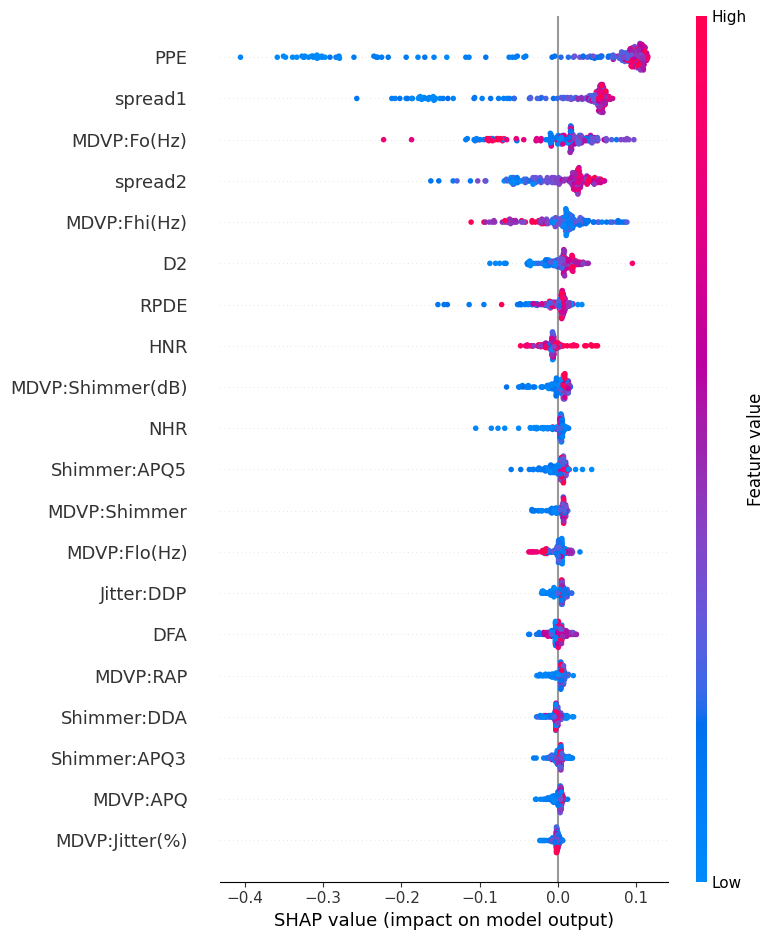

In [34]:
shap.summary_plot(shap_values, X)

In [35]:
shap_interaction_values = shap.TreeExplainer(model).shap_interaction_values(X.iloc[:20, :])

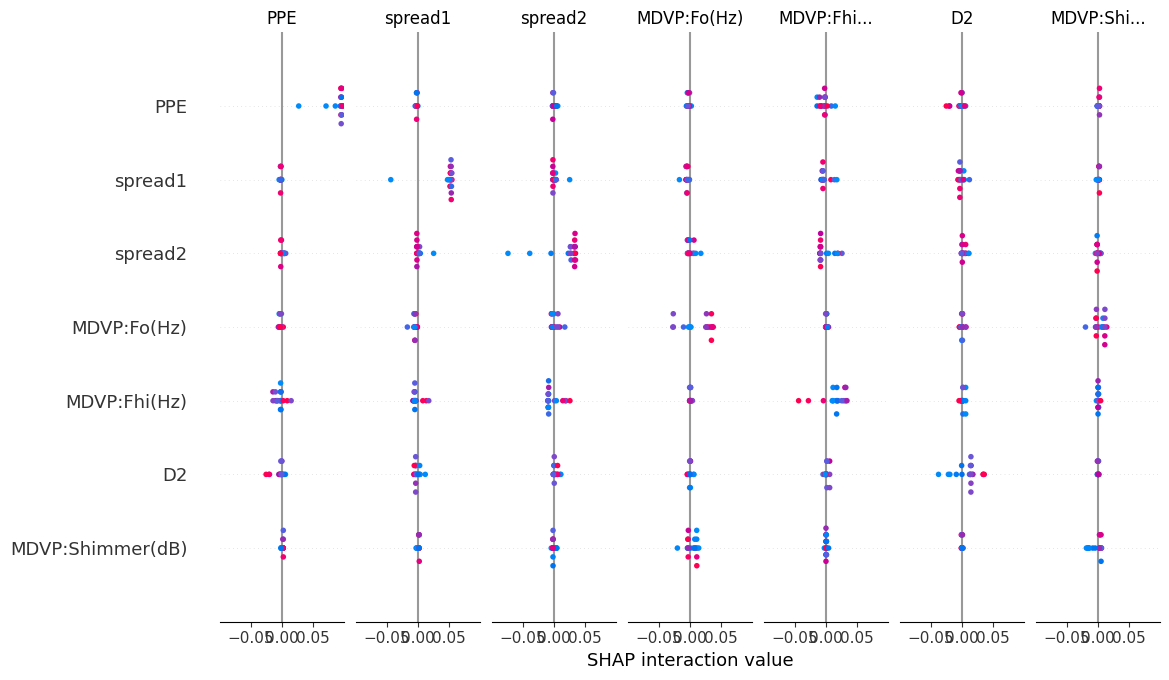

In [36]:
shap.summary_plot(shap_interaction_values, X.iloc[:20, :])

## Version 2

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde, entropy
from sklearn.ensemble import RandomForestRegressor
from sklearn.base import clone
import shap
from tqdm import tqdm
from sklearn.metrics import r2_score
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

class ESHAPExplainer:
    def __init__(self, model, X_train, y_train, beta=5.0, random_state=None):
        """
        Initialize E-SHAP explainer
        
        Args:
            model: Trained tree ensemble model (RandomForest, XGBoost, etc.)
            X_train: Training features
            y_train: Training labels
            beta: Temperature parameter for softmax weighting
            random_state: Random seed
        """
        self.model = model
        self.X_train = X_train
        self.y_train = y_train
        self.beta = beta
        self.random_state = random_state
        self.weights_ = self._compute_tree_weights()
        self.full_explainer = shap.TreeExplainer(model)
        
    def _compute_tree_weights(self):
        """Compute tree weights based on performance"""
        if hasattr(self.model, 'estimators_'):
            scores = []
            for tree in self.model.estimators_:
                pred = tree.predict(self.X_train)
                if len(pred.shape) > 1 and pred.shape[1] > 1:  # Classification
                    score = accuracy_score(self.y_train, np.argmax(pred, axis=1))
                else:  # Regression
                    score = r2_score(self.y_train, pred)
                scores.append(score)
            
            # Softmax weighting with temperature control
            max_score = np.max(scores)
            exp_vals = np.exp(self.beta * (np.array(scores) - max_score))
            return exp_vals / np.sum(exp_vals)
        else:
            # Single tree model
            return np.array([1.0])
    
    def explain(self, x, n_samples=500, alpha=1.0):
        """
        Compute E-SHAP values with uncertainty quantification
        
        Args:
            x: Input instance to explain
ç            alpha: Dirichlet concentration parameter
            
        Returns:
            Dictionary with SHAP distributions and uncertainty metrics
        """
        np.random.seed(self.random_state)
        n_trees = len(self.model.estimators_)
        n_features = x.shape[1]
        phi_dist = np.zeros((n_samples, n_features))
        
        for s in tqdm(range(n_samples), desc="Sampling hypothesis space"):
            # Dirichlet-weighted tree sampling
            dirichlet_weights = np.random.dirichlet(alpha * self.weights_)
            tree_indices = np.random.choice(
                n_trees, 
                size=n_trees, 
                p=dirichlet_weights
            )
            
            # Create sub-ensemble with sampled trees
            sub_ensemble = [self.model.estimators_[i] for i in tree_indices]
            temp_model = clone(self.model)
            temp_model.estimators_ = sub_ensemble
            
            # Compute SHAP values for sub-ensemble
            explainer = shap.TreeExplainer(temp_model)
            phi = explainer.shap_values(x)
            # Handle multi-class output
            phi_dist[s] = phi[0] if isinstance(phi, list) else phi
        
        # Compute uncertainty metrics
        results = {
            "mean": np.mean(phi_dist, axis=0),
            "std": np.std(phi_dist, axis=0),
            "ci_95": np.percentile(phi_dist, [2.5, 97.5], axis=0),
            "entropy": self._compute_entropy(phi_dist),
            "sign_stability": self._compute_sign_stability(phi_dist),
            "samples": phi_dist
        }
        return results
    
    def _compute_entropy(self, phi_dist):
        """Compute explanation entropy for each feature"""
        entropies = []
        for i in range(phi_dist.shape[1]):
            hist, bin_edges = np.histogram(phi_dist[:, i], bins=10, density=True)
            bin_probs = hist * np.diff(bin_edges)
            entropies.append(entropy(bin_probs))
        return np.array(entropies)
    
    def _compute_sign_stability(self, phi_dist):
        """Compute sign stability for each feature"""
        mean_sign = np.sign(np.mean(phi_dist, axis=0))
        stability = np.mean(np.sign(phi_dist) == mean_sign[np.newaxis, :], axis=0)
        return stability    
    
    def plot_uncertainty_bars(self, result, feature_names, title="E-SHAP Values with Epistemic Uncertainty"):
        """
        Plot SHAP values with uncertainty bars and comprehensive legend
        """
        plt.figure(figsize=(14, 10))
        order = np.argsort(result['mean'])
        y_pos = np.arange(len(feature_names))
        
        # Calculate absolute SHAP for color coding
        abs_mean = np.abs(result['mean'])
        norm = plt.Normalize(abs_mean.min(), abs_mean.max())
        colors = plt.cm.viridis(norm(abs_mean[order]))
        
        # Create plot with error bars
        bars = plt.barh(
            y_pos, 
            result['mean'][order],
            xerr=2*result['std'][order],
            capsize=5,
            alpha=0.85,
            color=colors,
            ecolor='darkred'
        )
        
        # Add feature values and uncertainty metrics
        for i, (mean_val, std_val, feat_name) in enumerate(zip(
            result['mean'][order], 
            2*result['std'][order],
            [feature_names[i] for i in order]
        )):
            plt.text(
                mean_val + 0.05 if mean_val > 0 else mean_val - 0.15, 
                i, 
                f"{mean_val:.3f} ± {std_val:.3f}",
                va='center',
                fontsize=10
            )
            sign_stab = result['sign_stability'][order][i]
            plt.text(
                -0.22 if mean_val > 0 else 0.05, 
                i, 
                f"Sign: {sign_stab:.1%}",
                va='center',
                fontsize=9,
                color='dimgrey'
            )
        
        plt.yticks(y_pos, [feature_names[i] for i in order])
        plt.xlabel('SHAP Value (Impact on Prediction)', fontsize=12)
        plt.title(title, fontsize=16, pad=20)
        plt.grid(axis='x', linestyle='--', alpha=0.4)
        
        # Create comprehensive legend
        legend_elements = [
            mpatches.Patch(color='darkred', label='2σ Uncertainty Interval'),
            Line2D([0], [0], marker='o', color='w', 
                   markerfacecolor='lightgray', markersize=10, label='Feature Importance\n(Color intensity → Magnitude)'),
            Line2D([0], [0], marker='', color='w', 
                   label=f"Sign Stability: Probability that\nfeature's impact direction is consistent"),
        ]
        
        plt.legend(
            handles=legend_elements, 
            loc='lower right',
            frameon=True,
            framealpha=0.9,
            fontsize=10
        )
        
        # Add colorbar for SHAP magnitude
        sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=plt.gca(), pad=0.01)
        cbar.set_label('Absolute SHAP Value Magnitude', fontsize=10)
        
        plt.tight_layout()
        plt.show()
    
    def plot_uncertainty_distribution(self, result, feature_names, feature_idx, title="SHAP Value Distribution"):
        """
        Plot kernel density estimate with enhanced annotations
        """
        plt.figure(figsize=(12, 7))
        samples = result['samples'][:, feature_idx]
        
        # Kernel density estimation
        kde = gaussian_kde(samples)
        x = np.linspace(min(samples)*1.2, max(samples)*1.2, 1000)
        plt.plot(x, kde(x), lw=2.5, color='navy', label='Probability Density')
        
        # Uncertainty metrics
        mean_val = result['mean'][feature_idx]
        ci_low, ci_high = result['ci_95'][:, feature_idx]
        std_val = result['std'][feature_idx]
        
        plt.axvline(mean_val, color='crimson', linestyle='-', lw=2, label='Mean SHAP Value')
        plt.axvspan(
            ci_low,
            ci_high,
            alpha=0.25, 
            color='skyblue',
            label='95% Credible Interval'
        )
        
        # Add distribution characteristics
        plt.axvline(0, color='black', linestyle=':', alpha=0.7, lw=1)
        plt.text(
            0.01, 0.92, 
            f"Epistemic Uncertainty: High\n(Std = {std_val:.3f})" if std_val > 0.15 else f"Epistemic Uncertainty: Low\n(Std = {std_val:.3f})",
            transform=plt.gca().transAxes,
            fontsize=12,
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray')
        )
        
        # Add sign stability indicator
        sign_stab = result['sign_stability'][feature_idx]
        stability_text = "Direction Certain" if sign_stab > 0.9 else "Direction Uncertain" if sign_stab < 0.7 else "Direction Mostly Stable"
        plt.text(
            0.01, 0.82, 
            f"{stability_text}\n(Sign Stability = {sign_stab:.1%})",
            transform=plt.gca().transAxes,
            fontsize=11,
            color='green' if sign_stab > 0.9 else 'red' if sign_stab < 0.7 else 'orange',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray')
        )
        
        plt.xlabel(f'SHAP Value for {feature_names[feature_idx]}', fontsize=12)
        plt.ylabel('Probability Density', fontsize=12)
        plt.title(f"{title}\n{feature_names[feature_idx]}", fontsize=15, pad=15)
        plt.legend(loc='upper right', fontsize=10)
        plt.grid(alpha=0.2)
        plt.tight_layout()
        plt.show()
    
    def plot_uncertainty_heatmap(self, result, feature_names, title="SHAP Uncertainty Metrics"):
        """
        Enhanced heatmap with colorbar and annotations
        """
        plt.figure(figsize=(14, 8))
        
        # Prepare data matrix
        metrics = np.vstack([
            result['mean'],
            result['std'],
            result['entropy'],
            result['sign_stability']
        ])
        
        # Create custom colormap
        cmap = plt.cm.coolwarm
        
        # Plot heatmap
        ax = sns.heatmap(
            metrics,
            annot=True,
            fmt=".3f",
            cmap=cmap,
            center=0,
            xticklabels=feature_names,
            yticklabels=['SHAP Mean', 'Std Dev', 'Explanation Entropy', 'Sign Stability'],
            annot_kws={"fontsize":10},
            cbar_kws={'label': 'Metric Value'}
        )
        
        # Add feature importance indicators
        max_shap = np.max(result['mean'])
        for i, val in enumerate(result['mean']):
            importance = val / max_shap
            ax.add_patch(plt.Rectangle((i, -0.1), 1, 0.1, 
                fill=True, 
                color=plt.cm.viridis(importance),
                alpha=0.7,
                transform=ax.get_xaxis_transform()
            ))
        
        plt.title(title, fontsize=16, pad=20)
        plt.xticks(rotation=45, ha='right', fontsize=10)
        plt.yticks(fontsize=11, rotation=0)
        plt.xlabel('Features', fontsize=12)
        plt.ylabel('Uncertainty Metrics', fontsize=12)
        
        # Add colorbar legend
        cbar = ax.collections[0].colorbar
        cbar.set_label('Metric Value', fontsize=11)
        
        # Add importance bar legend
        importance_legend = [
            mpatches.Patch(color=plt.cm.viridis(0.2), label='Low Importance'),
            mpatches.Patch(color=plt.cm.viridis(0.5), label='Medium Importance'),
            mpatches.Patch(color=plt.cm.viridis(0.8), label='High Importance')
        ]
        plt.legend(
            handles=importance_legend, 
            title='Feature Importance',
            loc='upper right',
            bbox_to_anchor=(1.15, 1.05),
            frameon=True
        )
        
        plt.tight_layout()
        plt.show()
    
    def plot_uncertainty_comparison(self, result, feature_names, title="Uncertainty Metric Comparison"):
        """
        Enhanced comparison plot with unified color scheme
        """
        fig, axes = plt.subplots(3, 1, figsize=(14, 16), sharey=True)
        plt.suptitle(title, fontsize=18, y=0.95)
        
        # Sort by SHAP magnitude
        order = np.argsort(result['mean'])
        sorted_features = [feature_names[i] for i in order]
        
        # Create consistent color mapping
        colors = plt.cm.plasma(np.linspace(0, 1, len(feature_names)))
        
        # Standard Deviation plot
        axes[0].barh(
            sorted_features,
            result['std'][order],
            color=colors,
            alpha=0.85,
            edgecolor='gray',
            linewidth=0.5
        )
        axes[0].set_title('Standard Deviation of SHAP Values', fontsize=14, pad=12)
        axes[0].set_xlabel('Magnitude of Uncertainty', fontsize=11)
        axes[0].axvline(np.mean(result['std']), color='red', linestyle='--', alpha=0.7)
        axes[0].text(
            np.mean(result['std']) + 0.01, len(feature_names)*0.8, 
            f'Mean: {np.mean(result["std"]):.3f}',
            color='red',
            fontsize=10
        )
        axes[0].grid(axis='x', alpha=0.2)
        
        # Entropy plot
        axes[1].barh(
            sorted_features,
            result['entropy'][order],
            color=colors,
            alpha=0.85,
            edgecolor='gray',
            linewidth=0.5
        )
        axes[1].set_title('Explanation Entropy (Information Uncertainty)', fontsize=14, pad=12)
        axes[1].set_xlabel('Entropy Value', fontsize=11)
        axes[1].axvline(np.mean(result['entropy']), color='red', linestyle='--', alpha=0.7)
        axes[1].text(
            np.mean(result['entropy']) + 0.01, len(feature_names)*0.8, 
            f'Mean: {np.mean(result["entropy"]):.3f}',
            color='red',
            fontsize=10
        )
        axes[1].grid(axis='x', alpha=0.2)
        
        # Sign Stability plot
        bars = axes[2].barh(
            sorted_features,
            result['sign_stability'][order],
            color=colors,
            alpha=0.85,
            edgecolor='gray',
            linewidth=0.5
        )
        axes[2].set_title('Sign Stability (Direction Consistency)', fontsize=14, pad=12)
        axes[2].set_xlabel('Probability of Consistent Direction', fontsize=11)
        axes[2].set_xlim(0, 1)
        axes[2].axvline(0.9, color='green', linestyle=':', alpha=0.7)
        axes[2].axvline(0.7, color='orange', linestyle=':', alpha=0.7)
        axes[2].text(0.91, len(feature_names)*0.1, 'High Confidence', color='green', fontsize=9)
        axes[2].text(0.71, len(feature_names)*0.1, 'Medium Confidence', color='orange', fontsize=9)
        axes[2].text(0.4, len(feature_names)*0.1, 'Low Confidence', color='red', fontsize=9)
        axes[2].grid(axis='x', alpha=0.2)
        
        # Add value labels
        for ax in axes:
            for bar in ax.patches:
                width = bar.get_width()
                label_x = width if width > 0 else 0.01
                ax.text(
                    label_x + 0.005,
                    bar.get_y() + bar.get_height()/2,
                    f'{width:.3f}',
                    ha='left' if width > 0 else 'right',
                    va='center',
                    fontsize=9
                )
        
        # Add unified legend
        fig.legend(
            [mpatches.Patch(color=c) for c in colors],
            sorted_features,
            title='Features (sorted by SHAP magnitude)',
            loc='lower center',
            ncol=4,
            bbox_to_anchor=(0.5, 0.01),
            fontsize=10
        )
        
        # plt.tight_layout(rect=[0, 0.05, 1, 0.95])
        plt.show()



/Users/DubeyA-Dev/miniconda3/envs/taylor/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/DubeyA-Dev/miniconda3/envs/taylor/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/DubeyA-Dev/miniconda3/envs/taylor/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/DubeyA-Dev/miniconda3/envs/taylor/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/DubeyA-Dev/miniconda3/envs/taylor/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but De


Feature Impact Summary with Uncertainty Quantification:
- MDVP:Fo(Hz): -0.0671 ± 0.0881 (95% CI: [-0.3215, 0.0285], Sign Stability: 85.20%)
- MDVP:Fhi(Hz): -0.0727 ± 0.0675 (95% CI: [-0.2314, 0.0000], Sign Stability: 92.40%)
- MDVP:Flo(Hz): -0.0145 ± 0.0538 (95% CI: [-0.1732, 0.0513], Sign Stability: 58.00%)
- MDVP:Jitter(%): -0.0028 ± 0.0263 (95% CI: [-0.0542, 0.0174], Sign Stability: 23.60%)
- MDVP:Jitter(Abs): 0.0015 ± 0.0045 (95% CI: [-0.0001, 0.0170], Sign Stability: 33.20%)
- MDVP:RAP: -0.0027 ± 0.0106 (95% CI: [-0.0315, 0.0069], Sign Stability: 36.60%)
- MDVP:PPQ: -0.0002 ± 0.0097 (95% CI: [-0.0219, 0.0177], Sign Stability: 35.80%)
- Jitter:DDP: 0.0004 ± 0.0066 (95% CI: [-0.0077, 0.0126], Sign Stability: 24.60%)
- MDVP:Shimmer: -0.0006 ± 0.0156 (95% CI: [-0.0407, 0.0384], Sign Stability: 35.80%)
- MDVP:Shimmer(dB): -0.0029 ± 0.0114 (95% CI: [-0.0351, 0.0188], Sign Stability: 50.40%)
- Shimmer:APQ3: -0.0024 ± 0.0131 (95% CI: [-0.0388, 0.0221], Sign Stability: 38.00%)
- Shimmer:A

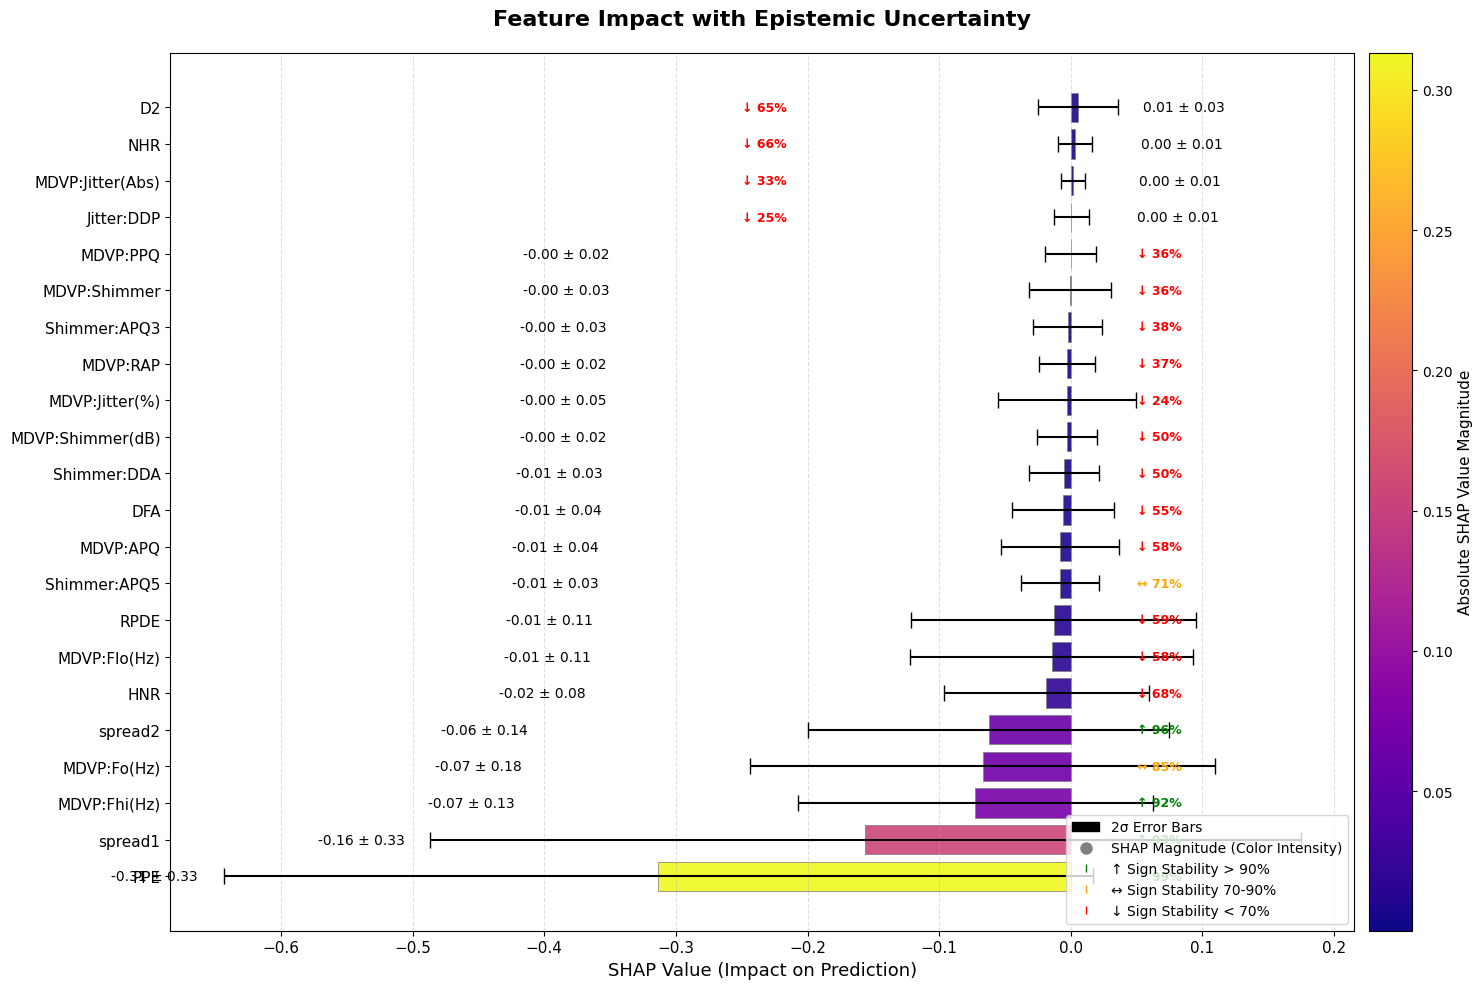

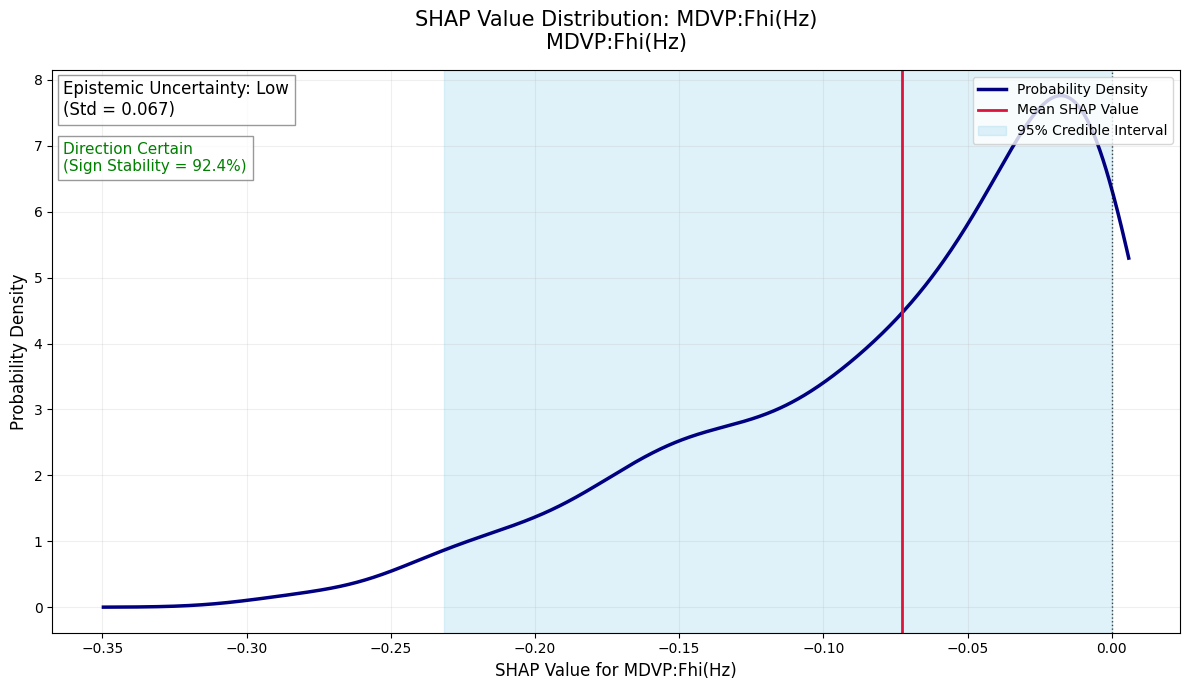

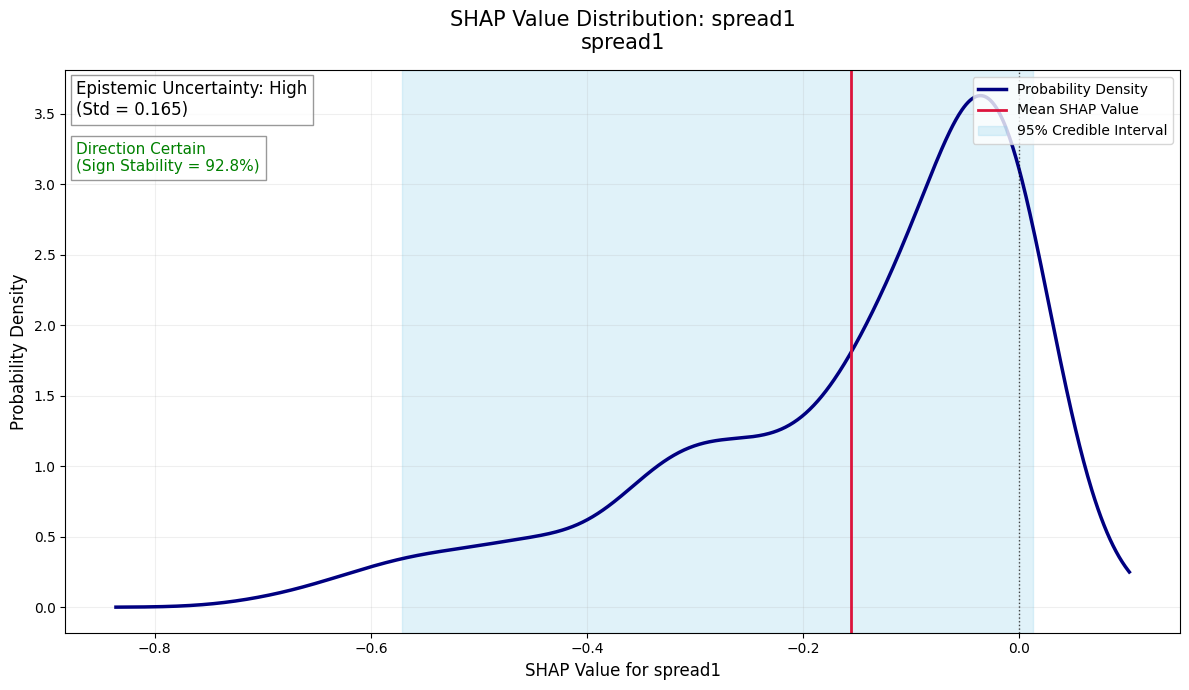

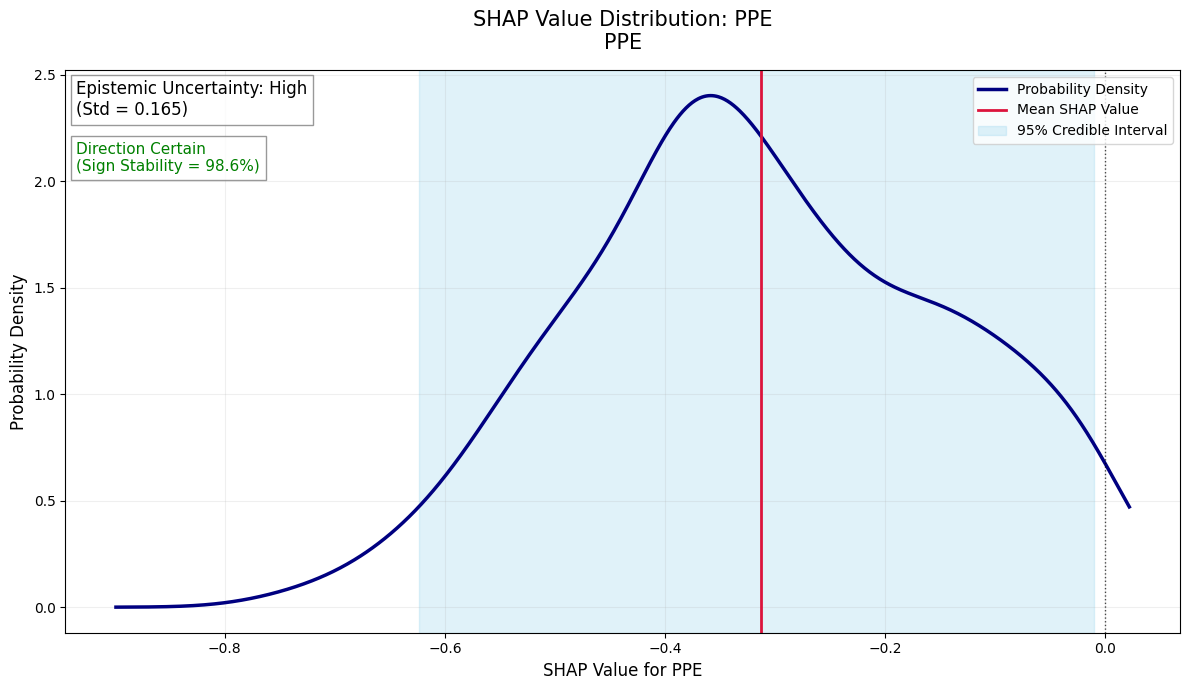

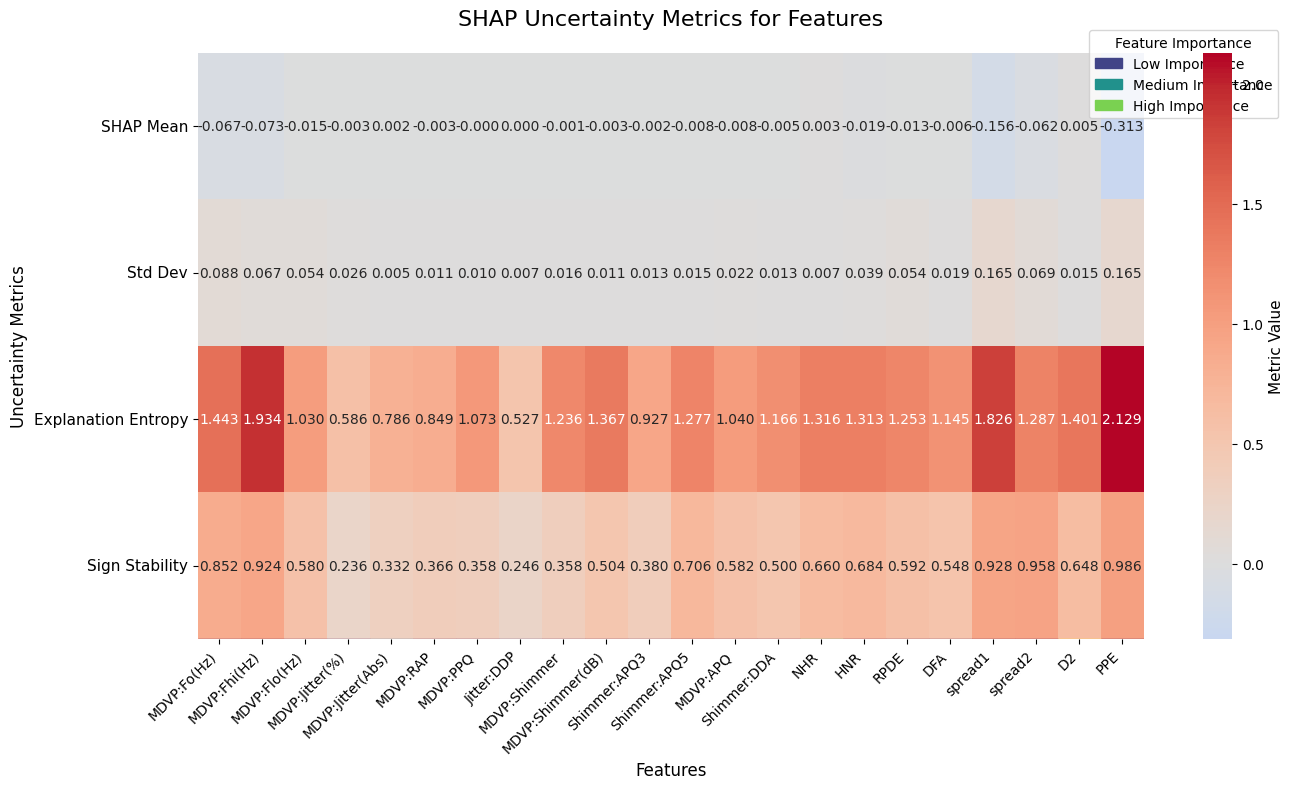

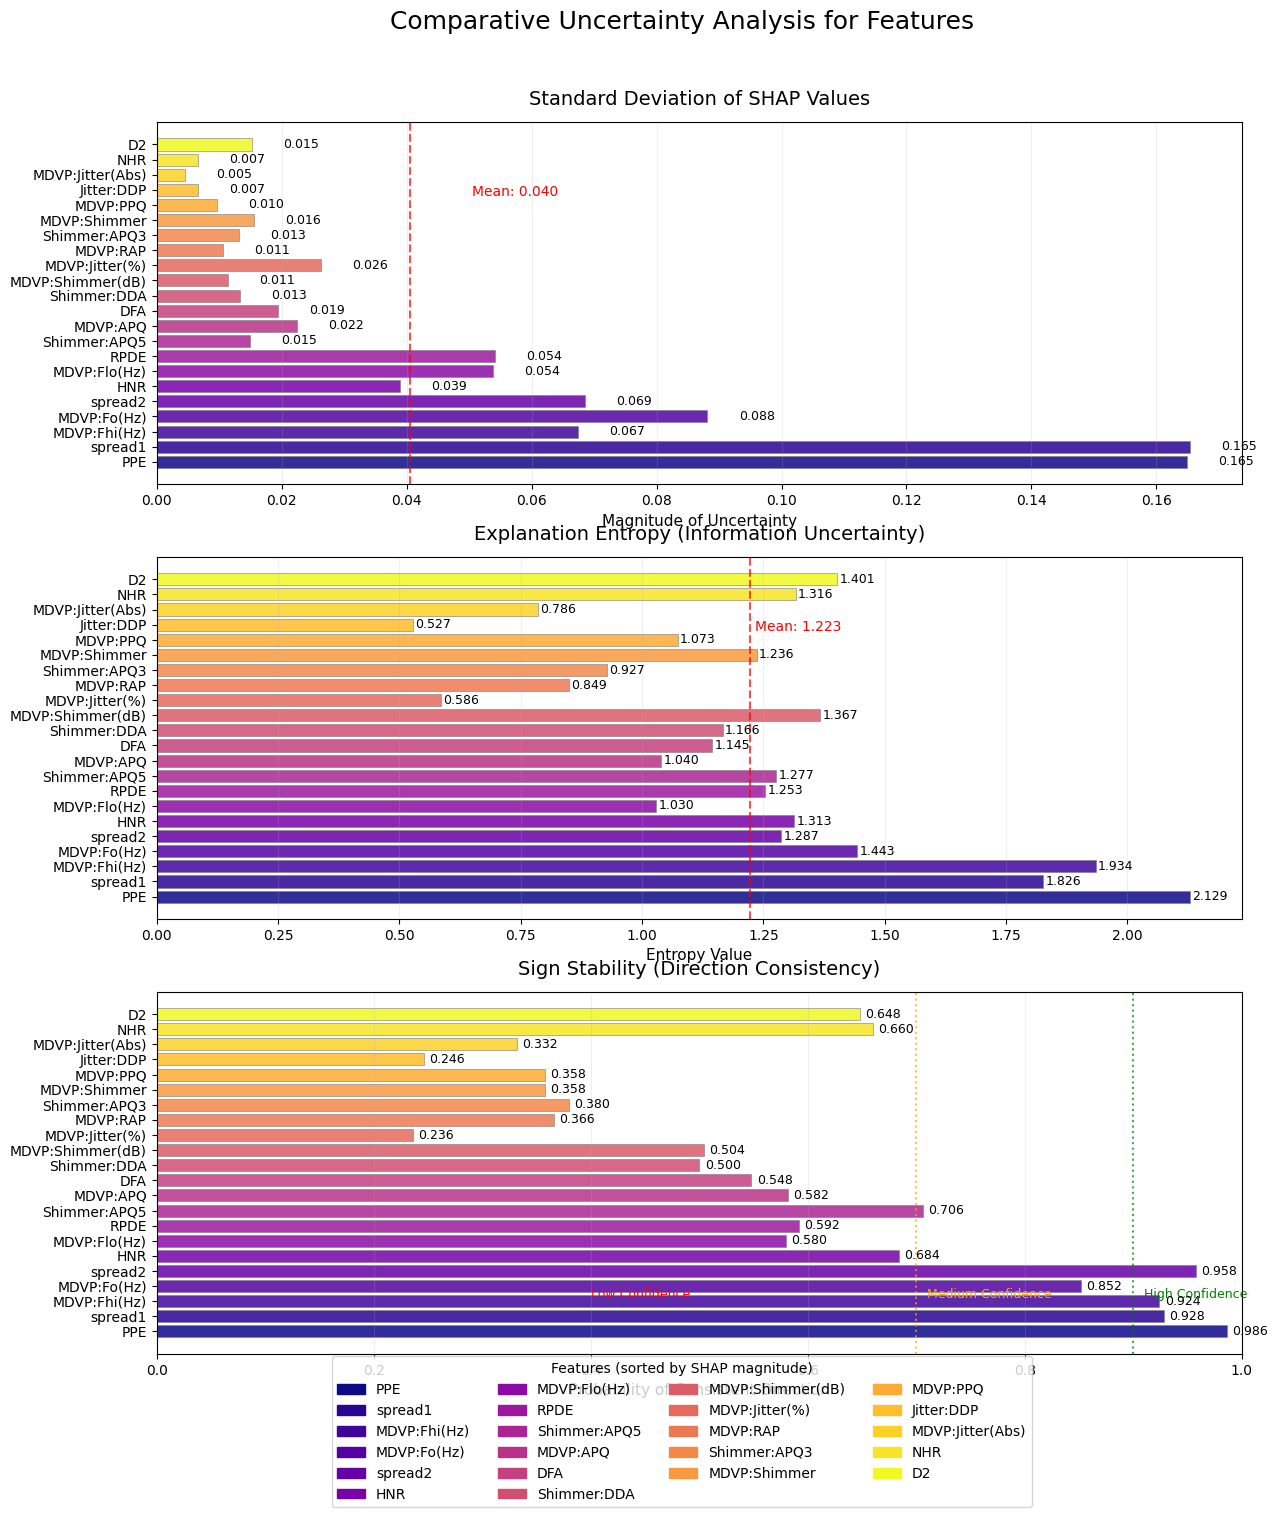

In [47]:


model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# Initialize E-SHAP explainer
eshap = ESHAPExplainer(model, X, y, beta=5.0, random_state=42)

# Explain an instance
instance = X[42:43]  # Select an interesting instance
result = eshap.explain(instance, n_samples=500)

print("\n" + "="*80)
print("Feature Impact Summary with Uncertainty Quantification:")
for i, name in enumerate(feature_names):
    print(f"- {name}: {result['mean'][i]:.4f} ± {result['std'][i]:.4f} "
            f"(95% CI: [{result['ci_95'][0][i]:.4f}, {result['ci_95'][1][i]:.4f}], "
            f"Sign Stability: {result['sign_stability'][i]:.2%})")
print("="*80 + "\n")

# Visualizations
eshap.plot_uncertainty_bars(result, feature_names, 
                            "Feature Impact with Epistemic Uncertainty")

# Plot distributions for top 3 features
top_features = np.argsort(np.abs(result['mean']))[-3:]
for idx in top_features:
    eshap.plot_uncertainty_distribution(result, feature_names, idx, 
                                        f"SHAP Value Distribution: {feature_names[idx]}")

eshap.plot_uncertainty_heatmap(result, feature_names, 
                                "SHAP Uncertainty Metrics for Features")

eshap.plot_uncertainty_comparison(result, feature_names, 
                                "Comparative Uncertainty Analysis for Features")

In [39]:
# importances = model.feature_importances_
# forest_importances = pd.Series(importances, index=feature_names)

# import matplotlib.pyplot as plt

# plt.bar(X.columns, forest_importances.values)

In [40]:
forest_importances

MDVP:Fo(Hz)         0.100241
MDVP:Fhi(Hz)        0.058331
MDVP:Flo(Hz)        0.029003
MDVP:Jitter(%)      0.012051
MDVP:Jitter(Abs)    0.006372
MDVP:RAP            0.012584
MDVP:PPQ            0.009805
Jitter:DDP          0.011908
MDVP:Shimmer        0.014428
MDVP:Shimmer(dB)    0.014305
Shimmer:APQ3        0.012563
Shimmer:APQ5        0.021016
MDVP:APQ            0.012310
Shimmer:DDA         0.017244
NHR                 0.028281
HNR                 0.037045
RPDE                0.047296
DFA                 0.024263
spread1             0.153202
spread2             0.046131
D2                  0.036547
PPE                 0.295073
dtype: float64